In [12]:
import zipfile
with zipfile.ZipFile('/content/archive (1).zip','r') as z:
  z.extractall('/content/')
  print(z.namelist())

['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [14]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (768, 7)

Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Missing values:
 Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Data types:
 Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


In [15]:
df.columns = df.columns.str.strip()
df = df.dropna()
print("Shape after cleaning:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape after cleaning: (740, 7)
Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [16]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [17]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


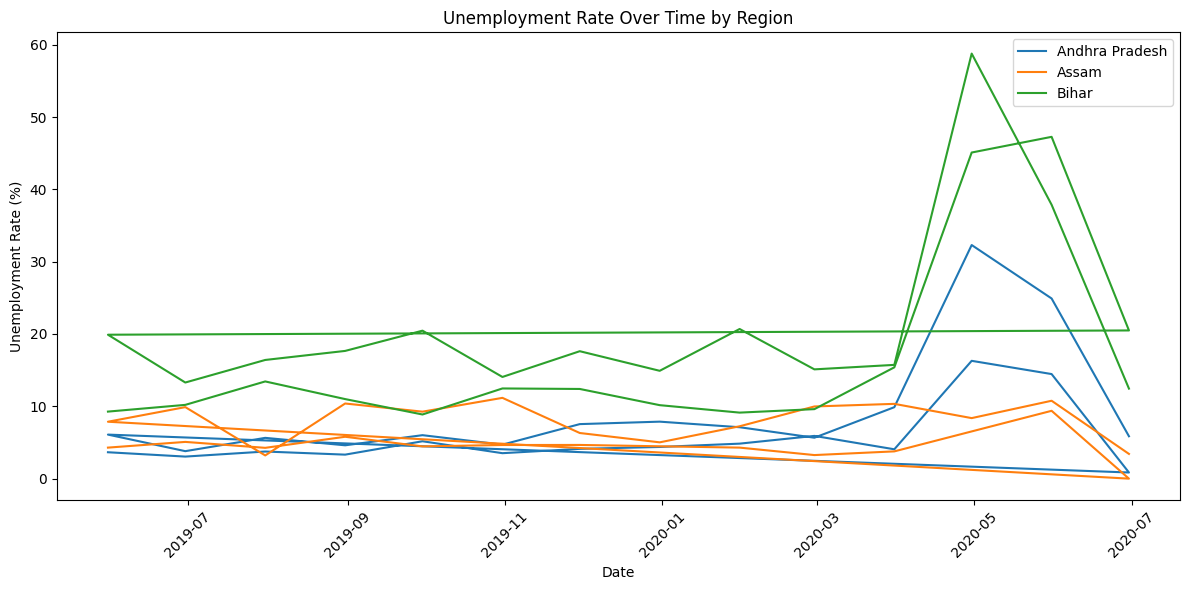

In [18]:
top_regions = df['Region'].unique()[:3]
plt.figure(figsize=(12, 6))
for region in top_regions:
    subset = df[df['Region'] == region]
    plt.plot(subset['Date'], subset['Estimated Unemployment Rate (%)'], label=region)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time by Region")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

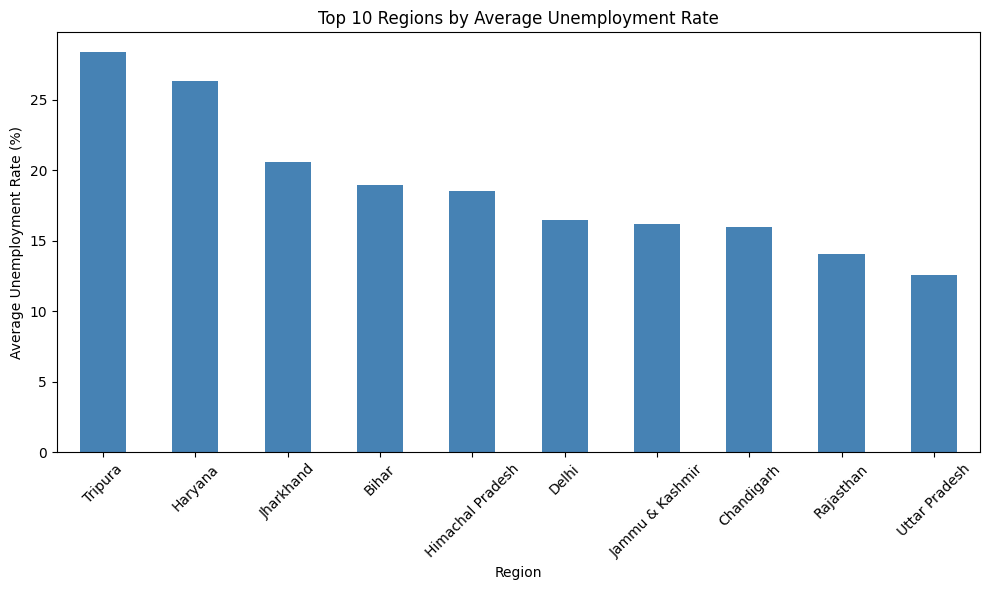

In [19]:
avg_by_region = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
avg_by_region.plot(kind='bar', color='steelblue')
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

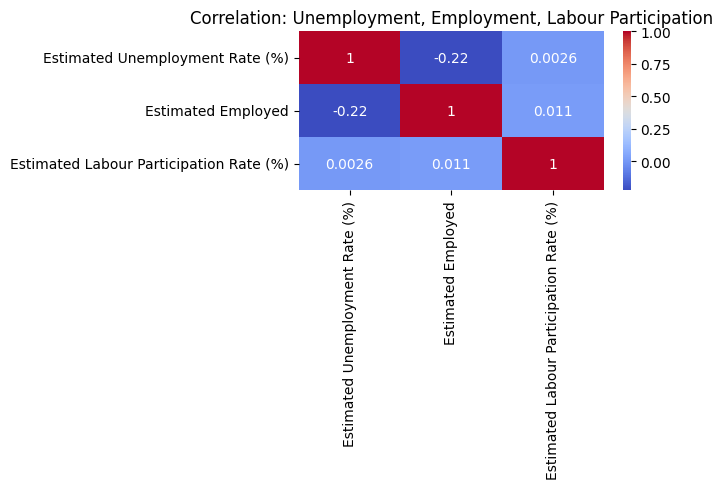

In [20]:
plt.figure(figsize=(7, 5))
corr_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation: Unemployment, Employment, Labour Participation")
plt.tight_layout()
plt.show()

Pre-COVID average unemployment rate: 9.51%
Post-COVID average unemployment rate: 17.77%


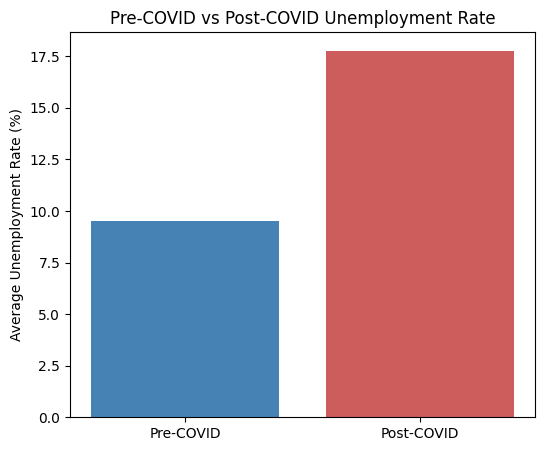

In [21]:
covid_cutoff = pd.Timestamp('2020-03-01')
pre_covid = df[df['Date'] < covid_cutoff]['Estimated Unemployment Rate (%)'].mean()
post_covid = df[df['Date'] >= covid_cutoff]['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-COVID average unemployment rate: {pre_covid:.2f}%")
print(f"Post-COVID average unemployment rate: {post_covid:.2f}%")

plt.figure(figsize=(6, 5))
plt.bar(['Pre-COVID', 'Post-COVID'], [pre_covid, post_covid], color=['steelblue', 'indianred'])
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.show()


## Observations
- Tripura and Haryana show the highest average unemployment rates among all regions, both well above 25%.
- Unemployment rate, employment, and labour participation rate show notable correlations, reflecting how these factors move together across regions and time.
- The Pre-COVID vs Post-COVID comparison shows a dramatic jump — average unemployment nearly doubled after March 2020, confirming the severe economic impact of the pandemic lockdowns.

## Conclusion
This analysis reveals significant regional and temporal variation in India's unemployment rates.
Key findings:

1. Unemployment nearly doubled during the COVID-19 period, highlighting the need for emergency
   economic support mechanisms during future crises.
2. States like Tripura and Haryana consistently show high unemployment and may benefit from
   targeted job creation programs or skill development initiatives.
3. The relationship between labour participation and unemployment suggests that policies
   should address both job creation and workforce engagement simultaneously.

This analysis could help policymakers prioritize regional interventions and prepare
contingency plans for future economic shocks.